<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Pr%C3%A1ctica04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construccion de casas (miles) | Ventas de linea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'construccion_de_casas': [2.0,2.5,3.2,3.6,3.7,4.0,4.2,4.6,4.8,5.0],
    'ventas_de_linea_blanca': [5.0,5.5,6.0,7.0,7.2,7.7,8.4,9.0,9.7,10.0],
})

df

,construccion_de_casas,ventas_de_linea_blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


1.   **Establesca una variable dependiente ($Y$) y una variable independiente ($X$)**

+ $Y$: es la venta de línea blanca debido a que dependen de la venta de casas.
+ $X$: son las construcción de casas ya que estas son independientes de que halla o no halla ventas de artículos de línea blanca.

In [ ]:
# Y: venta de linea blanca
# X: construccion de casas

X = df["construccion_de_casas"]
Y = df["ventas_de_linea_blanca"]

2. **Realice un diagrama de dispersión para estos datos.**

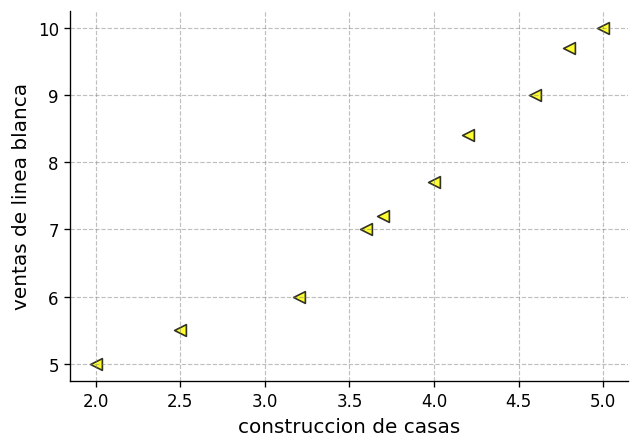

In [ ]:
import matplotlib.pyplot as plt

# Configuración del gráfico
plt.figure(figsize=(6, 4), dpi=120)

# Gráfico de dispersión con tus datos reales
plt.scatter(
    X, Y,
    marker="<",
    color='yellow',
    edgecolor='black',
    alpha=0.8,
    s=50
)

# Etiquetas personalizadas para tu contexto
plt.xlabel('construccion de casas', fontsize=12)
plt.ylabel('ventas de linea blanca', fontsize=12)

# Ajustes visuales
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.grid(visible=True, linestyle='--', linewidth=0.7, alpha=0.5, color="gray")

# Mostrar el gráfico
plt.show()

3. **¿Los datos soportan la suposición de linealidad?**

Si, porque los datos al aumentar la construccion de casas aumentan las ventas de linea blanca formando una linea diagonal que va de las esquina izquierda inferior hacia la esquina superior derecha.

4. **Calcule el coeficiente de correlación e interprete el resultado.**

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
valor_p:  0.0000


El coeficiente de correlacion es $r=-0.9808$, este valor indica que la correlacion es fuerte, dado que esta muy cerca de 1. Ademas el que sea negativa, implica que aumentar la construccion de casa ($X$) aumenta las ventas de linea blanca ($Y$)

5. **Calcule el coeficiente de determinación e interprete el resultado.**


In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant (X)
modelo = sm.OLS (Y,x_constante).fit ()
y_calculada = modelo.predict (x_constante )

modelo.params

,0
const,1.016760
construccion_de_casas,1.737564


In [ ]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  96.19%


Con coeficiente de determinación de $$r^2=0.9619$$ indica que con las ausencias estoy justificando en un $96.19\%$ la variabilidad en las ventas de linea blanca . Por lo que el modelo puede tener una buena capacidad de predicción.

6. **Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión**

In [ ]:
modelo.params

,0
const,1.016760
construccion_de_casas,1.737564


La ecuación de la recta es:

$$
\hat{y}=1.016760+1.737564x
$$

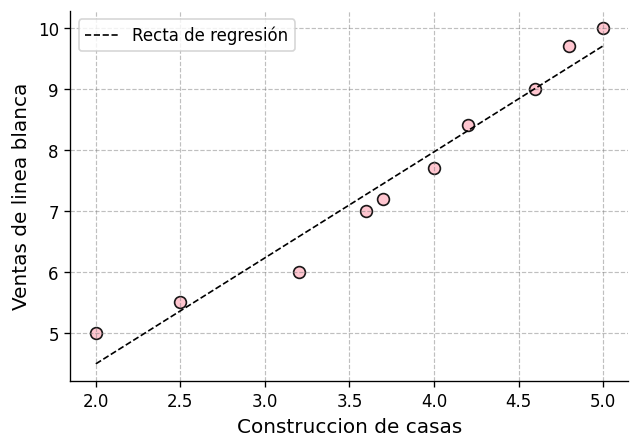

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Construccion de casas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Ventas de linea blanca', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

7. **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$



In [ ]:
modelo.conf_int(alpha=0.05)

,0,1
const,-0.074848,2.108368
construccion_de_casas,1.455693,2.019435


El verdadero $b_0$ está entre $-0.074848$ y $2.108368$ con una confianza del 95%. Esto indica que sin construccion de casas ($X=0$) tiene una categoría de ventas de linea blanca ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $1.455693$ y $2.019435$ con un 95% de confianza. Dado que dentro de este intervalo está el valor de cero, entonces la relación no es significativa.

8. **Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [ ]:
residuales = modelo.resid

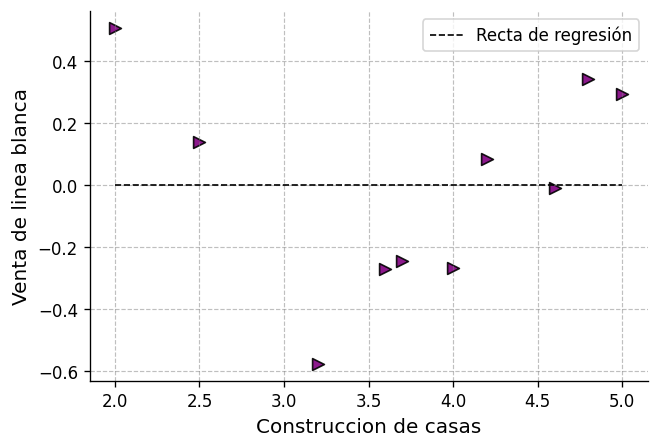

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker=">",       # forma: googlear "matplotlib.markers"
    color='purple',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Construccion de casas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Venta de linea blanca', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:


+ Linealidad: Parece que no, porque noy hay lineas paralelas en el grafico
+ Normalidad: No cumple con la normalidad, porque los puntos no se encuentran cerca de la linea
+ Homoscedasticidad: Parece que sí cumple con la homoscedasticidad, porque los puntos se encuentran dispersos en el grafico
+ Independencia: Sí cumple, porque los puntos estan disperson por diferentes partes.

9. **Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.8463507249054649


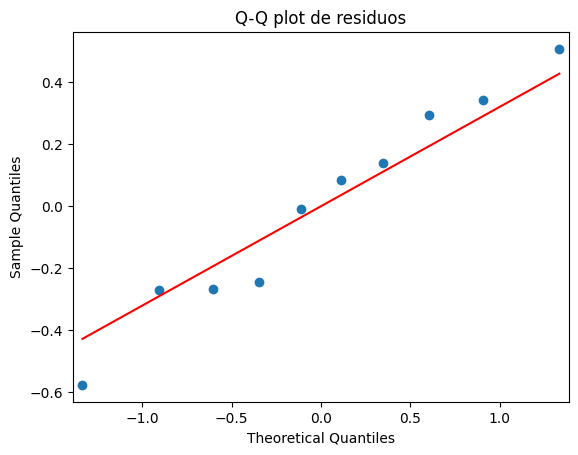

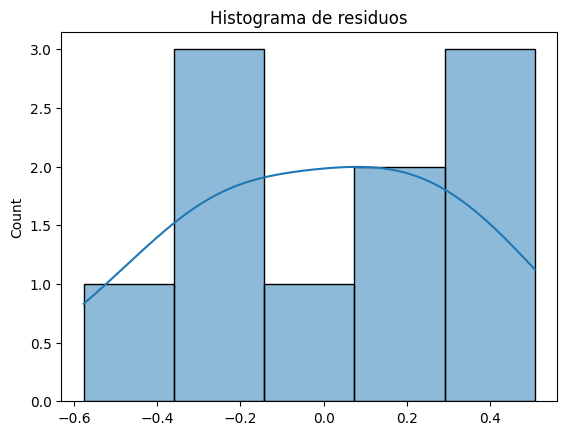

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

10. **Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.1581



11. **Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

Si el modelo cumple con todos los supuestos, es confiable para interpolación.

In [ ]:
# mínimo construccion de casas: 2.0
# máximo construccion de casas: 5.0

# interpolar, valores de x entre 2.0 y 5.0

# interpolar
y_3 = modelo.predict([1, 3])
y_4 = modelo.predict([1, 4])

print(f"Para x = 3, y =  {y_3[0]: 0.4f}")
print(f"Para x = 4, y =  {y_4[0]: 0.4f}")

Para x = 3, y =   6.2295
Para x = 4, y =   7.9670


La extrapolación siempre debe hacerse con cuidado, aunque cumpla con todos los supuestos.

In [ ]:
# mínimo construccion de casas: 2.0
# máximo construccion de casas: 5.0

# Extrapolar, valores de x que no estén entre 2.0 y 5.0

y_1 = modelo.predict([[1, 1]])

print(f"Para x = 1, y =  {y_1[0]: 0.4f}")

Para x = 1, y =   2.7543


Con una unidad se espera que el nivel de produción aumenten los gastos generales de 2. Este valor se obtuvo por medio de extrapolación, por lo que se toma con reservas.

12. **Realice una tabla ANOVA e interprete el resultado.**

In [ ]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''ventas_de_linea_blanca ~ construccion_de_casas''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
construccion_de_casas,1.0,25.976581,25.976581,202.069951,5.841003e-07
Residual,8.0,1.028419,0.128552,NaN,NaN


Si hay correlación porque el valor-p de $5.841003e-07$ es menor a un nivel de significancia $\alpha=0.05$.

En los residuales del anova se puede ver la diferencia entre el valor real observado y el valor predicho por el modelo (la media de su respectivo grupo).